# Synthetic Voluntary Attrition Intervention Learning Loop — Walkthrough

This notebook is the learning layer for the repository.

The purpose is to walk through the project step by step, from synthetic data generation to governance checks and visual reporting.

This notebook uses only synthetic data generated by the project code. It does not use, include, reproduce, reference, or depend on any real customer, member, employer, financial, operational, confidential, or proprietary organisation data.

Recommended use:

1. Run each cell manually.
2. Inspect the outputs.
3. Connect each technical step with the business decision logic.
4. Before committing the notebook, clear outputs if they become too large.

## Project map

The repository has four complementary layers:

- `src/` contains the engineered pipeline.
- `tests/` validates the pipeline.
- `README.md` and `MODEL_CARD.md` explain the portfolio and governance logic.
- `notebooks/` contains this learning walkthrough.

This notebook does not replace the source code. It helps you understand and explain the source code.

In [1]:
from pathlib import Path
import os
import sys

import pandas as pd
from IPython.display import display, Image

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop


In [2]:
from src.config import get_profile

from src.synthetic_data import (
    generate_customer_month_panel,
    save_synthetic_panel_outputs,
    summarise_synthetic_panel,
    synthetic_panel_summary_as_text,
)

from src.feature_engineering import (
    build_feature_table,
    feature_table_summary_as_text,
    save_feature_table_outputs,
    summarise_feature_table,
)

from src.rules_baseline import (
    rules_metrics_as_text,
    run_rules_baseline,
    save_rules_baseline_outputs,
)

from src.model_training import (
    model_metrics_as_text,
    run_model_v1,
    save_model_v1_outputs,
)

from src.intervention_policy import (
    create_intervention_list,
    intervention_summary_as_text,
    save_intervention_outputs,
    summarise_intervention_list,
)

from src.treatment_log import (
    generate_treatment_log,
    save_treatment_log_outputs,
    summarise_treatment_log,
    treatment_log_summary_as_text,
)

from src.model_v2_learning import (
    model_v2_metrics_as_text,
    run_model_v2,
    save_model_v2_outputs,
)

from src.governance_reporting import (
    run_governance_reporting,
    save_governance_reporting_outputs,
)

from src.visual_reporting import run_visual_reporting_from_outputs

print("Project imports completed successfully.")

Project imports completed successfully.


## 1. Load the synthetic project profile

The profile defines the size and configuration of the synthetic learning-loop experiment.

In [3]:
profile = get_profile()

profile_name = getattr(profile, "profile_name", "deep")
target_column = getattr(profile, "target_column", "voluntary_attrition_next_90d")

profile_summary = {
    "profile_name": profile_name,
    "n_customers": getattr(profile, "n_customers", None),
    "n_months": getattr(profile, "n_months", None),
    "target_column": target_column,
    "random_seed": getattr(profile, "random_seed", None),
    "rules_baseline_version": getattr(profile, "rules_baseline_version", None),
    "ml_model_v1_version": getattr(profile, "ml_model_v1_version", None),
    "ml_model_v2_version": getattr(profile, "ml_model_v2_version", None),
    "intervention_capacity": getattr(profile, "intervention_capacity", None),
    "treatment_share": getattr(profile, "treatment_share", None),
    "control_share": getattr(profile, "control_share", None),
}

display(pd.Series(profile_summary, name="value").to_frame())

,value
profile_name,deep
n_customers,25000
n_months,24
target_column,voluntary_attrition_next_90d
random_seed,None
rules_baseline_version,None
ml_model_v1_version,None
ml_model_v2_version,None
intervention_capacity,None
treatment_share,None


## 2. Generate the synthetic customer-month panel

This creates a synthetic financial-services customer-month panel.

Business interpretation: each row represents a customer observed at a monthly snapshot.

In [4]:
synthetic_panel = generate_customer_month_panel(profile=profile)
synthetic_summary = summarise_synthetic_panel(synthetic_panel)
synthetic_output_paths = save_synthetic_panel_outputs(synthetic_panel)

print(synthetic_panel_summary_as_text(synthetic_summary))
print(f"Saved to: {synthetic_output_paths['synthetic_panel']}")

display(synthetic_panel.head())

Synthetic panel summary
Rows: 600,000
Customers: 25,000
Months: 24
Columns: 30
Target rate: 7.93%
Missing values: 0
Memory usage: 227.48 MB
Saved to: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/data/synthetic/synthetic_customer_month_panel.csv


,customer_id,snapshot_month,customer_month_index,tenure_months,age_band,region_type,relationship_segment,active_products,has_savings_product,has_credit_product,has_digital_wallet,savings_balance_index,credit_balance_index,relationship_value_index,app_logins_30d,web_logins_30d,digital_transactions_30d,last_digital_activity_days,digital_engagement_score,digital_engagement_trend_3m,contact_attempts_90d,successful_contacts_90d,complaint_count_180d,average_resolution_days,process_friction_score,satisfaction_proxy_score,repayment_behaviour_score,days_past_due_band,recent_credit_application_flag,voluntary_attrition_next_90d
0,1,2024-01,1,19,30-44,suburban,established,1,1,0,1,61.59,24.05,44.60,16,4,9,9,69.85,-2.60,0,0,0,0.37,20.19,86.58,97.97,no_credit_product,0,0
1,1,2024-02,2,20,30-44,suburban,established,3,1,1,0,60.10,16.44,54.78,4,2,6,41,30.35,24.79,2,2,1,1.79,27.51,71.76,74.80,current,0,1
2,1,2024-03,3,21,30-44,suburban,established,2,0,0,1,50.52,46.85,48.73,6,4,6,19,42.25,3.42,2,1,0,6.11,12.06,84.29,85.02,no_credit_product,0,0
3,1,2024-04,4,22,30-44,suburban,established,2,1,0,1,45.93,40.36,41.99,2,4,2,27,25.45,13.70,1,1,3,7.04,37.39,59.91,96.83,no_credit_product,0,0
4,1,2024-05,5,23,30-44,suburban,established,1,1,0,0,68.30,52.50,50.33,5,3,5,15,38.35,-10.48,0,0,1,2.63,20.18,68.59,68.24,no_credit_product,0,0


In [5]:
print("Synthetic panel shape:", synthetic_panel.shape)

display(synthetic_panel.dtypes.to_frame("dtype").head(20))
display(synthetic_panel.select_dtypes(include="number").describe().T.head(15))

Synthetic panel shape: (600000, 30)


,dtype
customer_id,int32
snapshot_month,object
customer_month_index,int16
tenure_months,int16
age_band,object
region_type,object
relationship_segment,object
active_products,int8
has_savings_product,int8
has_credit_product,int8


,count,mean,std,min,25%,50%,75%,max
customer_id,600000.0,12500.500000,7216.884373,1.00,6250.75,12500.50,18750.25,25000.0
customer_month_index,600000.0,12.500000,6.922192,1.00,6.75,12.50,18.25,24.0
tenure_months,600000.0,71.768560,35.215535,1.00,42.00,72.00,102.00,143.0
active_products,600000.0,3.502607,1.243815,1.00,3.00,3.00,4.00,7.0
has_savings_product,600000.0,0.824635,0.380279,0.00,1.00,1.00,1.00,1.0
has_credit_product,600000.0,0.474973,0.499374,0.00,0.00,0.00,1.00,1.0
has_digital_wallet,600000.0,0.489160,0.499883,0.00,0.00,0.00,1.00,1.0
savings_balance_index,600000.0,62.712407,16.125802,0.00,51.76,62.77,73.75,100.0
credit_balance_index,600000.0,39.084896,16.412316,0.00,27.88,39.05,50.19,100.0
relationship_value_index,600000.0,60.223050,14.871619,0.00,50.05,60.21,70.39,100.0


## 3. Build the engineered feature table

This converts raw synthetic customer-month observations into model-ready features.

Business interpretation: this is where raw behavioural, engagement, relationship, and risk signals become decision-ready variables.

In [6]:
feature_result = build_feature_table(synthetic_panel)
feature_table = feature_result.feature_table

feature_summary = summarise_feature_table(feature_table)
feature_output_paths = save_feature_table_outputs(feature_result)

print(feature_table_summary_as_text(feature_summary))
print(f"Saved to: {feature_output_paths['feature_table']}")

display(feature_table.head())

Feature table summary
Rows: 600,000
Customers: 25,000
Months: 24
Columns: 39
Features: 35
Numeric features: 31
Categorical features: 4
Target rate: 7.93%
Missing values: 0
Train rows: 400,000
Validation rows: 100,000
Test rows: 100,000
Saved to: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/feature_table.csv


,customer_id,snapshot_month,data_split,customer_month_index,tenure_months,active_products,has_savings_product,has_credit_product,has_digital_wallet,savings_balance_index,credit_balance_index,relationship_value_index,app_logins_30d,web_logins_30d,digital_transactions_30d,last_digital_activity_days,digital_engagement_score,digital_engagement_trend_3m,contact_attempts_90d,successful_contacts_90d,complaint_count_180d,average_resolution_days,process_friction_score,satisfaction_proxy_score,repayment_behaviour_score,recent_credit_application_flag,relationship_depth_score,digital_inactivity_flag,engagement_decline_flag,high_service_friction_flag,low_satisfaction_flag,credit_stress_score,relationship_health_score,value_at_risk_index,age_band,region_type,relationship_segment,days_past_due_band,voluntary_attrition_next_90d
0,1,2024-01,train,1,19,1,1,0,1,61.59,24.05,44.60,16,4,9,9,69.85,-2.60,0,0,0,0.37,20.19,86.58,97.97,0,25.67,0,0,0,0,0,60.35,17.68,30-44,suburban,established,no_credit_product,0
1,1,2024-02,train,2,20,3,1,1,0,60.10,16.44,54.78,4,2,6,41,30.35,24.79,2,2,1,1.79,27.51,71.76,74.80,0,51.96,0,0,0,0,5,47.07,29.00,30-44,suburban,established,current,1
2,1,2024-03,train,3,21,2,0,0,1,50.52,46.85,48.73,6,4,6,19,42.25,3.42,2,1,0,6.11,12.06,84.29,85.02,0,39.00,0,0,0,0,0,56.72,21.09,30-44,suburban,established,no_credit_product,0
3,1,2024-04,train,4,22,2,1,0,1,45.93,40.36,41.99,2,4,2,27,25.45,13.70,1,1,3,7.04,37.39,59.91,96.83,0,37.90,0,0,0,0,0,40.86,24.83,30-44,suburban,established,no_credit_product,0
4,1,2024-05,train,5,23,1,1,0,0,68.30,52.50,50.33,5,3,5,15,38.35,-10.48,0,0,1,2.63,20.18,68.59,68.24,0,27.82,0,1,0,0,0,42.68,28.85,30-44,suburban,established,no_credit_product,0


In [7]:
print("Feature table shape:", feature_table.shape)

if "split" in feature_table.columns and target_column in feature_table.columns:
    display(
        feature_table
        .groupby("split")[target_column]
        .agg(target_rate="mean", rows="count")
        .reset_index()
    )

display(feature_table.dtypes.to_frame("dtype").head(25))

Feature table shape: (600000, 39)


,dtype
customer_id,int32
snapshot_month,object
data_split,object
customer_month_index,int16
tenure_months,int16
active_products,int8
has_savings_product,int8
has_credit_product,int8
has_digital_wallet,int8
savings_balance_index,float64


## 4. Run the rules-based baseline

The rules baseline represents a transparent benchmark.

Business interpretation: before using machine learning, a team should understand how a simple rules approach performs.

In [8]:
rules_result = run_rules_baseline(feature_table)
rules_output_paths = save_rules_baseline_outputs(rules_result)

print(rules_metrics_as_text(rules_result.metrics))
print(f"Metrics saved to: {rules_output_paths['metrics']}")
print(f"Scored table saved to: {rules_output_paths['scored_table']}")

display(rules_result.metrics)
display(rules_result.scored_table.head())

Rules baseline metrics
    model_version      split   rows  target_rate  roc_auc  pr_auc  brier_score  precision_at_100  lift_at_100  precision_at_500  lift_at_500  precision_at_1000  lift_at_1000
rules_baseline_v1 validation 100000       0.0740   0.6381  0.1240       0.0818              0.29       3.9194             0.258       3.4870              0.226        3.0545
rules_baseline_v1       test 100000       0.0714   0.6399  0.1192       0.0802              0.25       3.4999             0.250       3.4999              0.220        3.0799
Metrics saved to: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/metrics_rules_baseline.csv
Scored table saved to: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/scored_customers_rules_baseline.csv


,model_version,split,rows,target_rate,roc_auc,pr_auc,brier_score,precision_at_100,lift_at_100,precision_at_500,lift_at_500,precision_at_1000,lift_at_1000
0,rules_baseline_v1,validation,100000,0.07399,0.638072,0.123992,0.081847,0.29,3.919449,0.258,3.486958,0.226,3.054467
1,rules_baseline_v1,test,100000,0.07143,0.639946,0.119171,0.080224,0.25,3.499930,0.250,3.499930,0.220,3.079938


,customer_id,snapshot_month,data_split,voluntary_attrition_next_90d,relationship_value_index,value_at_risk_index,relationship_health_score,rules_risk_score,rules_risk_decile
0,1,2024-01,train,0,44.60,17.68,60.35,0.131196,5
1,1,2024-02,train,1,54.78,29.00,47.07,0.174276,7
2,1,2024-03,train,0,48.73,21.09,56.72,0.124900,4
3,1,2024-04,train,0,41.99,24.83,40.86,0.210054,7
4,1,2024-05,train,0,50.33,28.85,42.68,0.321003,10


## 5. Train the first machine learning model

Model v1 predicts pre-intervention attrition risk.

Business interpretation: this is the first statistical prioritisation model, before learning from intervention outcomes.

In [9]:
model_v1_result = run_model_v1(feature_table)
model_v1_output_paths = save_model_v1_outputs(model_v1_result)

print(model_metrics_as_text(model_v1_result.metrics))
print(f"Metrics saved to: {model_v1_output_paths['metrics']}")
print(f"Scored table saved to: {model_v1_output_paths['scored_table']}")

display(model_v1_result.metrics)
display(model_v1_result.scored_table.head())

Model metrics
model_version      split   rows  target_rate  roc_auc  pr_auc  brier_score  precision_at_100  lift_at_100  precision_at_500  lift_at_500  precision_at_1000  lift_at_1000
  ml_model_v1 validation 100000       0.0740   0.6824  0.1525       0.0662              0.38       5.1358             0.290       3.9194              0.279        3.7708
  ml_model_v1       test 100000       0.0714   0.6844  0.1476       0.0641              0.43       6.0199             0.302       4.2279              0.274        3.8359
Metrics saved to: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/metrics_model_v1.csv
Scored table saved to: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/scored_customers_v1.csv


,model_version,split,rows,target_rate,roc_auc,pr_auc,brier_score,precision_at_100,lift_at_100,precision_at_500,lift_at_500,precision_at_1000,lift_at_1000
0,ml_model_v1,validation,100000,0.07399,0.682361,0.152452,0.066176,0.38,5.135829,0.290,3.919449,0.279,3.770780
1,ml_model_v1,test,100000,0.07143,0.684414,0.147597,0.064126,0.43,6.019880,0.302,4.227915,0.274,3.835923


,customer_id,snapshot_month,data_split,voluntary_attrition_next_90d,relationship_value_index,value_at_risk_index,relationship_health_score,model_v1_risk_score,model_v1_risk_decile
0,1,2024-01,train,0,44.60,17.68,60.35,0.082030,7
1,1,2024-02,train,1,54.78,29.00,47.07,0.116643,9
2,1,2024-03,train,0,48.73,21.09,56.72,0.079977,7
3,1,2024-04,train,0,41.99,24.83,40.86,0.152638,10
4,1,2024-05,train,0,50.33,28.85,42.68,0.116525,9


## 6. Create an intervention-prioritisation list

The intervention policy selects a capacity-constrained group of customers and assigns treatment/control groups.

Business interpretation: this connects predictive analytics to an operational intervention workflow.

In [10]:
intervention_result = create_intervention_list(
    scored_table=model_v1_result.scored_table,
    feature_table=feature_table,
    profile_name=profile_name,
)

intervention_list = intervention_result.intervention_list
intervention_summary = summarise_intervention_list(intervention_list)
intervention_output_paths = save_intervention_outputs(intervention_result)

print(intervention_summary_as_text(intervention_summary))
print(f"Saved to: {intervention_output_paths['intervention_list']}")

preview_columns = [
    col for col in [
        "customer_id",
        "snapshot_month",
        "model_risk_score",
        "recommended_action",
        "assignment_group",
    ]
    if col in intervention_list.columns
]

display(intervention_list[preview_columns].head(10) if preview_columns else intervention_list.head(10))

Intervention policy summary
Rows: 1,000
Unique customers: 1,000
Observed synthetic target rate: 20.10%
Average model risk score: 21.49%
Treatment rows: 800
Control rows: 200
Recommended action types: 5
Saved to: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/intervention_list_v1.csv


,customer_id,snapshot_month,recommended_action
0,21128,2025-12,service_recovery_case
1,15857,2025-12,service_recovery_case
2,2969,2025-12,service_recovery_case
3,1206,2025-12,digital_reactivation_nudge
4,3563,2025-12,service_recovery_case
5,23819,2025-12,service_recovery_case
6,7594,2025-12,service_recovery_case
7,13775,2025-12,service_recovery_case
8,18737,2025-12,service_recovery_case
9,23033,2025-12,service_recovery_case


## 7. Generate a synthetic treatment log

The treatment log simulates contact, completion, cost, and outcome information.

Business interpretation: this is what allows the second model to learn from action outcomes, not just historical risk.

In [11]:
treatment_result = generate_treatment_log(intervention_list)
treatment_log = treatment_result.treatment_log

treatment_summary = summarise_treatment_log(treatment_log)
treatment_output_paths = save_treatment_log_outputs(treatment_result)

print(treatment_log_summary_as_text(treatment_summary))
print(f"Saved to: {treatment_output_paths['treatment_log']}")

display(treatment_log.head(10))

for group_column in ["assignment_group", "treatment_group", "group"]:
    if group_column in treatment_log.columns:
        display(treatment_log.groupby(group_column).size().to_frame("rows"))
        break

Treatment log summary
Rows: 1,000
Treatment rows: 800
Control rows: 200
Pre-intervention target rate: 20.10%
Post-intervention target rate: 18.70%
Contact success rate: 73.38%
Treatment completion rate: 48.50%
Prevented attrition count: 14
Total intervention cost index: 2,325.22
Total retained value index: 678.60
Total net value index: -1,646.62
Saved to: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/treatment_log_v1.csv


,treatment_log_id,policy_rank,customer_id,snapshot_month,assigned_group,recommended_action,contact_channel,reason_code_1,reason_code_2,model_v1_risk_score,relationship_value_index,value_at_risk_index,relationship_health_score,voluntary_attrition_next_90d,contact_attempted,contact_success,treatment_completed,prevented_attrition_flag,post_intervention_attrition_next_90d,intervention_cost_index,retained_value_index,net_value_index
0,TLOG-000001,1,21128,2025-12,control,service_recovery_case,specialist_call,digital_inactivity,declining_engagement,0.522000,55.36,41.72,24.63,1,0,0,0,0,1,0.00,0.0,0.00
1,TLOG-000002,2,15857,2025-12,control,service_recovery_case,specialist_call,digital_inactivity,declining_engagement,0.510265,53.54,43.20,19.31,0,0,0,0,0,0,0.00,0.0,0.00
2,TLOG-000003,3,2969,2025-12,treatment,service_recovery_case,specialist_call,declining_engagement,service_friction,0.407415,30.40,30.40,0.00,1,1,0,0,0,1,5.00,0.0,-5.00
3,TLOG-000004,4,1206,2025-12,treatment,digital_reactivation_nudge,in_app_message,declining_engagement,weak_relationship_health,0.393270,23.82,15.99,32.88,1,1,1,1,0,1,2.03,0.0,-2.03
4,TLOG-000005,5,3563,2025-12,treatment,service_recovery_case,specialist_call,declining_engagement,service_friction,0.387286,31.96,24.24,24.14,0,1,1,0,0,0,5.00,0.0,-5.00
5,TLOG-000006,6,23819,2025-12,treatment,service_recovery_case,specialist_call,digital_inactivity,service_friction,0.386362,79.04,59.77,24.38,0,1,0,0,0,0,5.00,0.0,-5.00
6,TLOG-000007,7,7594,2025-12,control,service_recovery_case,specialist_call,declining_engagement,service_friction,0.372915,55.46,46.78,15.65,0,0,0,0,0,0,0.00,0.0,0.00
7,TLOG-000008,8,13775,2025-12,treatment,service_recovery_case,specialist_call,digital_inactivity,service_friction,0.370948,48.84,37.23,23.78,1,1,0,0,0,1,5.00,0.0,-5.00
8,TLOG-000009,9,18737,2025-12,treatment,service_recovery_case,specialist_call,service_friction,low_satisfaction,0.367022,51.29,40.97,20.12,1,1,1,0,0,1,5.00,0.0,-5.00
9,TLOG-000010,10,23033,2025-12,control,service_recovery_case,specialist_call,service_friction,low_satisfaction,0.350152,45.41,41.58,8.44,0,0,0,0,0,0,0.00,0.0,0.00


## 8. Train the treatment-aware machine learning model

Model v2 is trained after the synthetic intervention loop.

Business interpretation: this demonstrates a learning loop where treatment history can inform future prioritisation.

In [12]:
model_v2_result = run_model_v2(
    feature_table=feature_table,
    treatment_log=treatment_log,
)

model_v2_output_paths = save_model_v2_outputs(model_v2_result)

print(model_v2_metrics_as_text(model_v2_result.metrics))
print(f"Learning table saved to: {model_v2_output_paths['learning_table']}")
print(f"Metrics saved to: {model_v2_output_paths['metrics']}")
print(f"Scored table saved to: {model_v2_output_paths['scored_table']}")

display(model_v2_result.metrics)
display(model_v2_result.learning_table.head())

Model v2 metrics
              model_version      split  rows  target_rate  roc_auc  pr_auc  brier_score  precision_at_50  lift_at_50  precision_at_100  lift_at_100  precision_at_200  lift_at_200
treatment_aware_ml_model_v2 validation   200        0.185   0.5463  0.2209       0.1575             0.22      1.1892              0.20       1.0811             0.185          1.0
treatment_aware_ml_model_v2       test   200        0.185   0.4707  0.2222       0.1676             0.20      1.0811              0.19       1.0270             0.185          1.0
Learning table saved to: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/treatment_learning_table_v2.csv
Metrics saved to: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/metrics_model_v2.csv
Scored table saved to: /Users/alberto/

,model_version,split,rows,target_rate,roc_auc,pr_auc,brier_score,precision_at_50,lift_at_50,precision_at_100,lift_at_100,precision_at_200,lift_at_200
0,treatment_aware_ml_model_v2,validation,200,0.185,0.546344,0.220875,0.157531,0.22,1.189189,0.20,1.081081,0.185,1.0
1,treatment_aware_ml_model_v2,test,200,0.185,0.470735,0.222249,0.167574,0.20,1.081081,0.19,1.027027,0.185,1.0


,treatment_log_id,policy_rank,customer_id,snapshot_month,assigned_group,recommended_action,contact_channel,reason_code_1,reason_code_2,model_v1_risk_score,contact_attempted,contact_success,treatment_completed,intervention_cost_index,post_intervention_attrition_next_90d,customer_month_index,tenure_months,active_products,has_savings_product,has_credit_product,has_digital_wallet,savings_balance_index,credit_balance_index,relationship_value_index,app_logins_30d,web_logins_30d,digital_transactions_30d,last_digital_activity_days,digital_engagement_score,digital_engagement_trend_3m,contact_attempts_90d,successful_contacts_90d,complaint_count_180d,average_resolution_days,process_friction_score,satisfaction_proxy_score,repayment_behaviour_score,recent_credit_application_flag,relationship_depth_score,digital_inactivity_flag,engagement_decline_flag,high_service_friction_flag,low_satisfaction_flag,credit_stress_score,relationship_health_score,value_at_risk_index,age_band,region_type,relationship_segment,days_past_due_band,assigned_treatment_flag,treatment_learning_split
0,TLOG-000001,1,21128,2025-12,control,service_recovery_case,specialist_call,digital_inactivity,declining_engagement,0.522000,0,0,0,0.00,1,24,33,2,0,0,0,65.84,48.31,55.36,0,3,3,61,13.45,-17.18,0,0,2,8.82,57.16,36.37,81.64,0,43.32,1,1,0,1,0,24.63,41.72,30-44,urban,emerging,no_credit_product,0,test
1,TLOG-000002,2,15857,2025-12,control,service_recovery_case,specialist_call,digital_inactivity,declining_engagement,0.510265,0,0,0,0.00,0,24,34,1,1,1,1,58.67,48.49,53.54,1,2,2,60,12.80,-33.23,0,0,3,9.70,58.81,37.19,79.20,0,31.21,1,1,0,1,5,19.31,43.20,45-59,regional,emerging,current,0,validation
2,TLOG-000003,3,2969,2025-12,treatment,service_recovery_case,specialist_call,declining_engagement,service_friction,0.407415,1,0,0,5.00,1,24,40,1,1,0,1,27.73,23.63,30.40,3,2,2,44,20.80,-24.65,5,2,6,17.62,99.47,5.53,57.02,0,28.08,0,1,1,1,0,0.00,30.40,30-44,urban,high_value,no_credit_product,1,train
3,TLOG-000004,4,1206,2025-12,treatment,digital_reactivation_nudge,in_app_message,declining_engagement,weak_relationship_health,0.393270,1,1,1,2.03,1,24,25,2,1,0,1,35.49,0.00,23.82,6,2,6,28,37.60,-33.15,0,0,2,10.83,46.90,51.23,71.20,0,35.01,0,1,0,0,0,32.88,15.99,18-29,suburban,core,no_credit_product,1,train
4,TLOG-000005,5,3563,2025-12,treatment,service_recovery_case,specialist_call,declining_engagement,service_friction,0.387286,1,1,0,5.00,0,24,61,3,1,0,1,38.02,12.03,31.96,1,1,2,44,15.60,-11.26,3,2,3,11.73,70.63,35.91,75.80,0,57.64,0,1,1,1,0,24.14,24.24,18-29,urban,core,no_credit_product,1,test


## 9. Run governance and model-comparison reporting

Governance checks confirm that the project remains clean, synthetic, and structurally valid.

Business interpretation: model development is not complete until it has controls, comparison logic, and documented limitations.

In [13]:
governance_result = run_governance_reporting(
    synthetic_panel=synthetic_panel,
    feature_table=feature_table,
    rules_metrics=rules_result.metrics,
    rules_scored_table=rules_result.scored_table,
    model_v1_metrics=model_v1_result.metrics,
    model_v1_scored_table=model_v1_result.scored_table,
    intervention_list=intervention_list,
    treatment_log=treatment_log,
    model_v2_metrics=model_v2_result.metrics,
    model_v2_learning_table=model_v2_result.learning_table,
    model_v2_scored_table=model_v2_result.scored_table,
)

governance_output_paths = save_governance_reporting_outputs(governance_result)

print(f"Model comparison saved to: {governance_output_paths['model_comparison']}")
print(f"Governance checks saved to: {governance_output_paths['governance_checks']}")

display(governance_result.model_comparison)
display(governance_result.governance_checks)

display(
    governance_result.governance_checks
    .groupby(["severity", "status"])
    .size()
    .reset_index(name="checks")
)

Model comparison saved to: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/model_comparison.csv
Governance checks saved to: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/governance_checks.csv


,model_version,model_family,prediction_objective,population,direct_comparison_group,split,rows,target_rate,roc_auc,pr_auc,brier_score,precision_at_50,lift_at_50,precision_at_100,lift_at_100,precision_at_200,lift_at_200,precision_at_500,lift_at_500,precision_at_1000,lift_at_1000
0,treatment_aware_ml_model_v2,treatment_aware_ml_model_v2,post_intervention_attrition_risk,intervention_candidate_population,post_intervention_learning_loop,test,200,0.18500,0.470735,0.222249,0.167574,0.20,1.081081,0.19,1.027027,0.185,1.0,NaN,NaN,NaN,NaN
1,treatment_aware_ml_model_v2,treatment_aware_ml_model_v2,post_intervention_attrition_risk,intervention_candidate_population,post_intervention_learning_loop,validation,200,0.18500,0.546344,0.220875,0.157531,0.22,1.189189,0.20,1.081081,0.185,1.0,NaN,NaN,NaN,NaN
2,ml_model_v1,ml_model_v1,pre_intervention_attrition_risk,full_customer_month_population,pre_intervention_ranking,test,100000,0.07143,0.684414,0.147597,0.064126,NaN,NaN,0.43,6.019880,NaN,NaN,0.302,4.227915,0.274,3.835923
3,rules_baseline_v1,rules_baseline,pre_intervention_attrition_risk,full_customer_month_population,pre_intervention_ranking,test,100000,0.07143,0.639946,0.119171,0.080224,NaN,NaN,0.25,3.499930,NaN,NaN,0.250,3.499930,0.220,3.079938
4,ml_model_v1,ml_model_v1,pre_intervention_attrition_risk,full_customer_month_population,pre_intervention_ranking,validation,100000,0.07399,0.682361,0.152452,0.066176,NaN,NaN,0.38,5.135829,NaN,NaN,0.290,3.919449,0.279,3.770780
5,rules_baseline_v1,rules_baseline,pre_intervention_attrition_risk,full_customer_month_population,pre_intervention_ranking,validation,100000,0.07399,0.638072,0.123992,0.081847,NaN,NaN,0.29,3.919449,NaN,NaN,0.258,3.486958,0.226,3.054467


,check_id,check_name,status,severity,details
0,GOV-001,synthetic_panel_has_rows,pass,critical,"Synthetic panel rows: 600,000"
1,GOV-002,synthetic_customer_month_key_unique,pass,critical,Duplicated synthetic customer-month keys: 0
2,GOV-003,synthetic_panel_has_no_missing_values,pass,critical,Missing values in synthetic panel: 0
3,GOV-004,feature_table_has_no_missing_values,pass,critical,Missing values in feature table: 0
4,GOV-005,feature_table_has_train_validation_test_splits,pass,critical,"Observed feature-table splits: ['test', 'train..."
5,GOV-006,feature_customer_month_key_unique,pass,critical,Duplicated feature-table customer-month keys: 0
6,GOV-007,rules_scored_rows_match_feature_table,pass,critical,"Rules scored rows: 600,000; feature rows: 600,000"
7,GOV-008,model_v1_scores_are_probabilities,pass,critical,All model v1 scores must be between 0 and 1.
8,GOV-009,intervention_list_uses_single_snapshot,pass,critical,Intervention snapshot count: 1
9,GOV-010,intervention_capacity_is_respected,pass,critical,"Rows: 1,000; configured capacity: 1,000"


,severity,status,checks
0,critical,pass,18
1,warning,pass,1


## 10. Generate visual reporting outputs

This produces portfolio-ready plots from the saved outputs.

Business interpretation: technical outputs become more useful when they can be explained visually to non-technical stakeholders.

In [14]:
visual_result = run_visual_reporting_from_outputs()

print(visual_result.as_text())

plot_dir = PROJECT_ROOT / "outputs" / "plots"
plot_paths = sorted(plot_dir.glob("*.png"))

print()
print("Generated plot files:")
for path in plot_paths:
    print(f"- {path}")

Visual reporting outputs
- model_comparison_auc: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/plots/model_comparison_auc.png
- model_comparison_pr_auc: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/plots/model_comparison_pr_auc.png
- intervention_action_mix: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/plots/intervention_action_mix.png
- treatment_outcomes: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfolio/[1] GitHub/[1] retention-intervention-learning-loop/outputs/plots/treatment_outcomes.png
- risk_score_distribution_v1: /Users/alberto/Desktop/untitled folder/Library/Documents/[5] Romero Torres & Co./[10] Portfol

intervention_action_mix.png


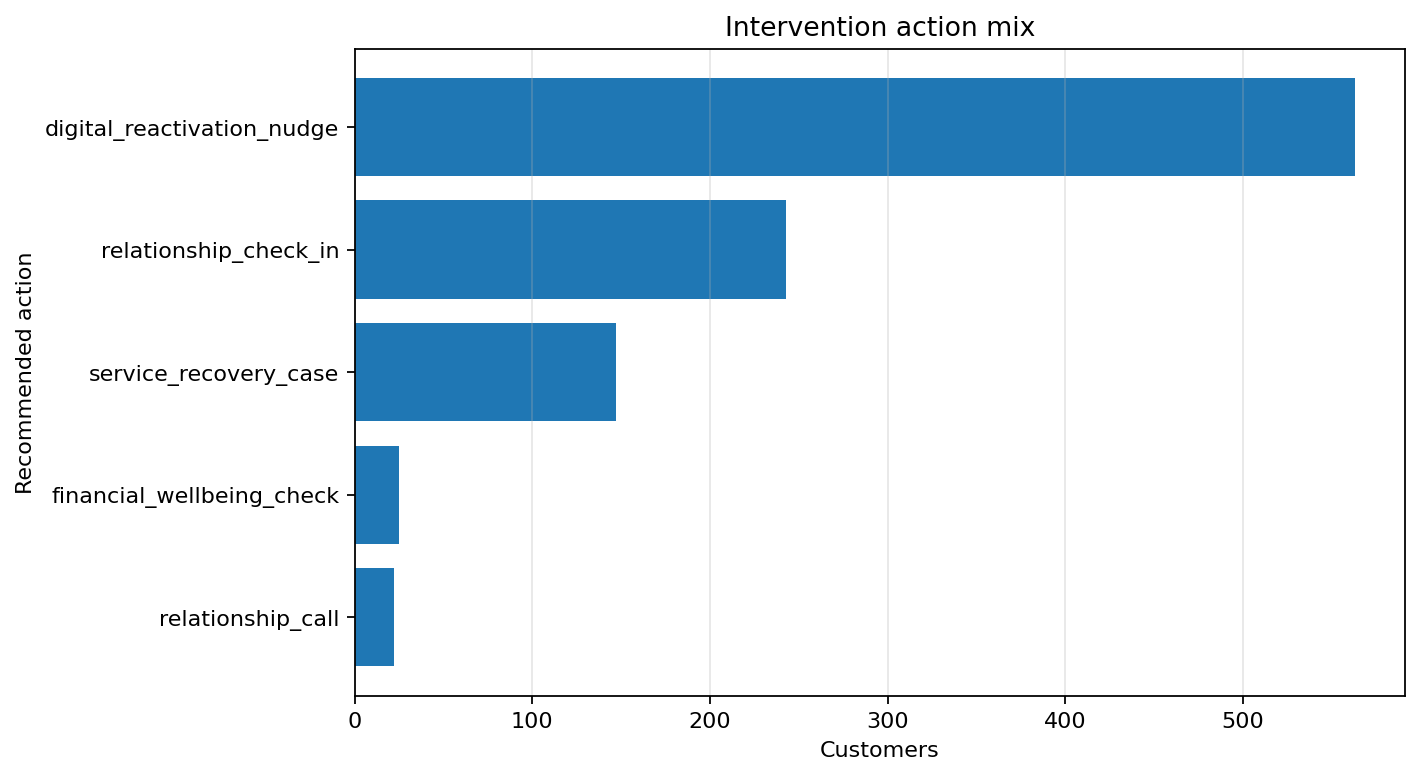

model_comparison_auc.png


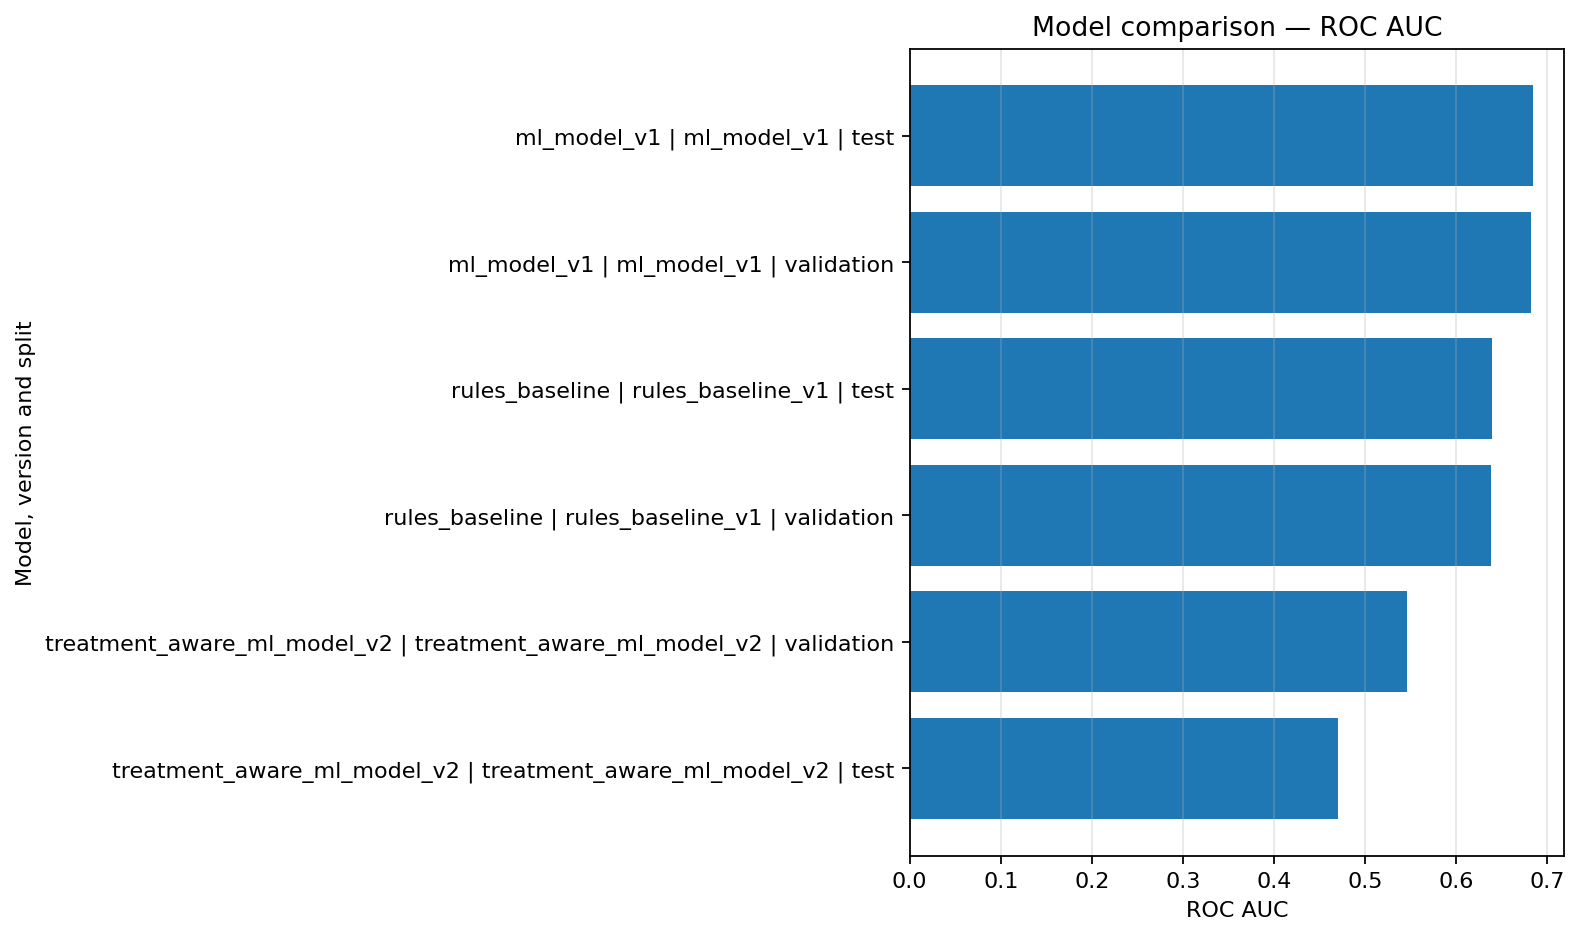

model_comparison_pr_auc.png


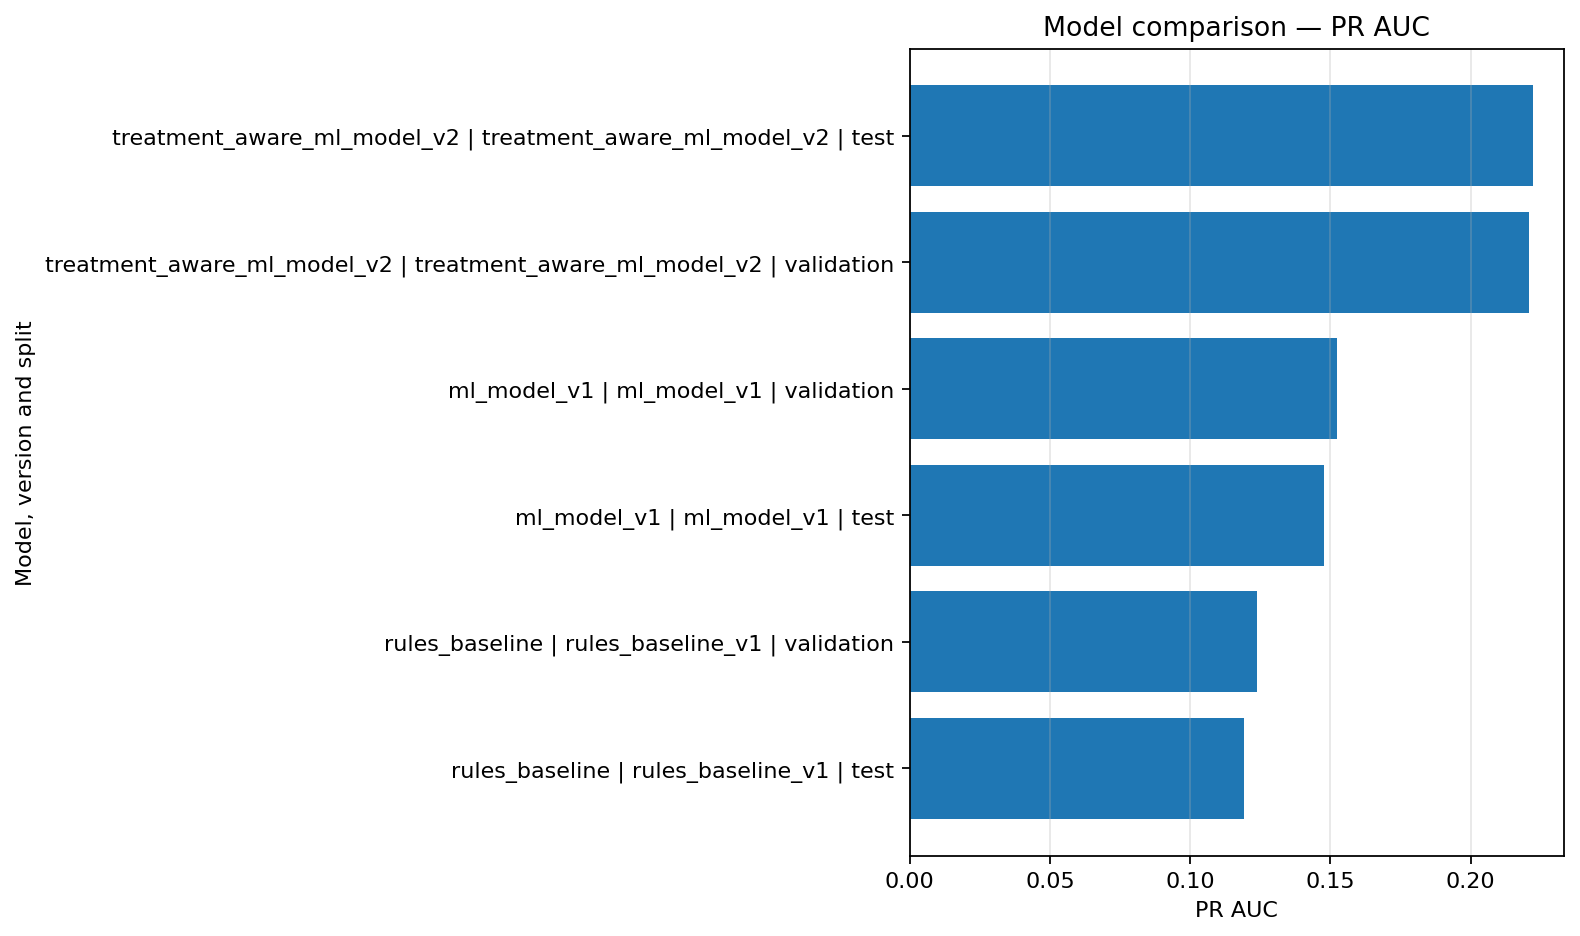

risk_score_distribution_v1.png


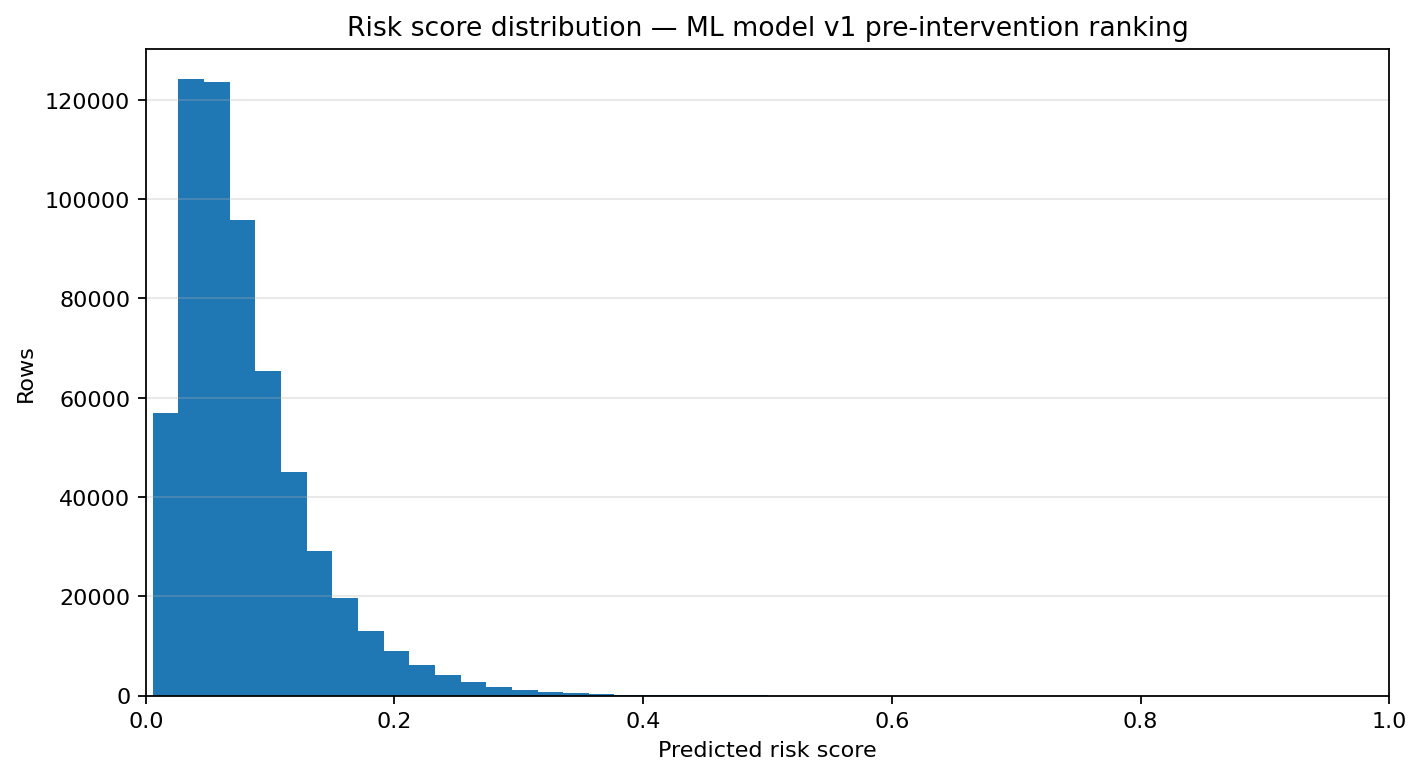

risk_score_distribution_v2.png


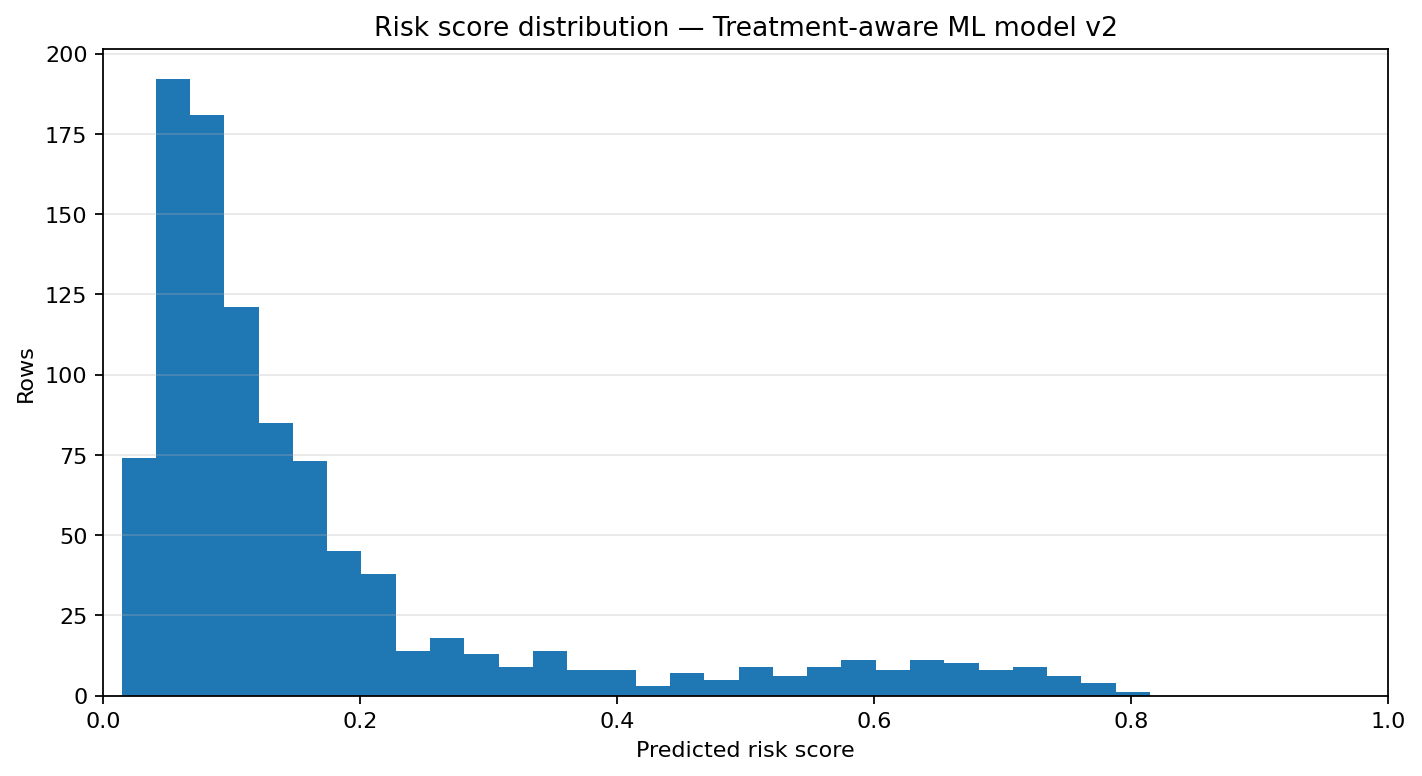

treatment_outcomes.png


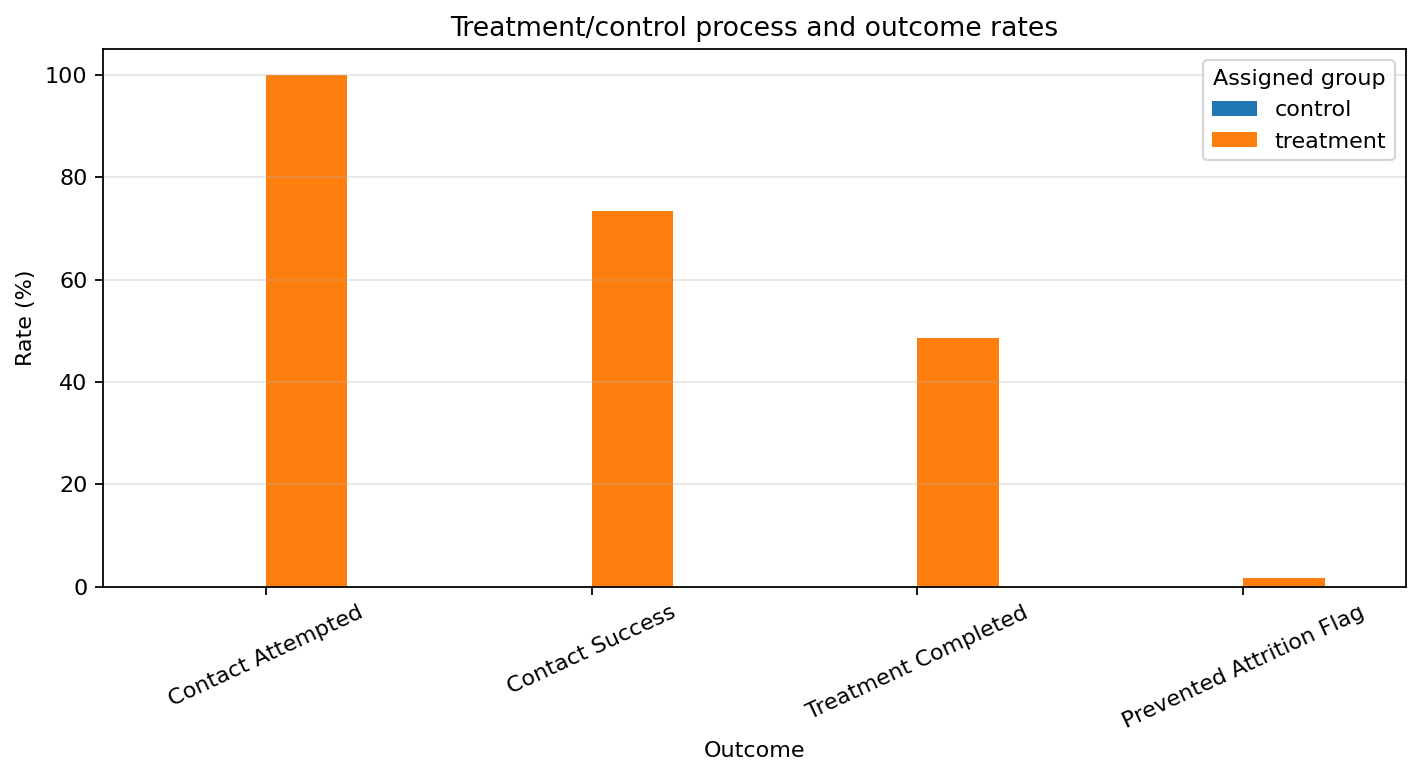

In [15]:
for path in sorted((PROJECT_ROOT / "outputs" / "plots").glob("*.png")):
    print(path.name)
    display(Image(filename=str(path), width=800))

## Learning checkpoint

At this point, the full learning loop has been executed interactively.

You should now be able to explain:

- Why synthetic data was used.
- How customer-month data becomes a feature table.
- Why a rules baseline is useful.
- What the first machine learning model contributes.
- How intervention design connects analytics to action.
- Why treatment/control logging matters.
- How the second model represents learning from intervention outcomes.
- Why governance checks and model cards are part of responsible analytics delivery.